The dataset was acquired from Cornell University’s NLP research group. 

In [5]:
cd "C:\Users\bhavi\Downloads\review_polarity"

C:\Users\bhavi\Downloads\review_polarity


In [6]:
#import libraries
import os
import pandas as pd

In [8]:
#read files and create dataset
data = []

pos_path = "txt_sentoken/pos"
neg_path = "txt_sentoken/neg"

# Positive reviews
for file in os.listdir(pos_path):
    with open(os.path.join(pos_path, file), encoding='utf-8') as f:
        data.append([f.read(), 1])   # 1 = positive

# Negative reviews
for file in os.listdir(neg_path):
    with open(os.path.join(neg_path, file), encoding='utf-8') as f:
        data.append([f.read(), 0])   # 0 = negative

# Convert to DataFrame
df = pd.DataFrame(data, columns=["review", "sentiment"])

df.head()

,review,sentiment
0,films adapted from comic books have had plenty...,1
1,every now and then a movie comes along from a ...,1
2,you've got mail works alot better than it dese...,1
3,""" jaws "" is a rare film that grabs your atten...",1
4,moviemaking is a lot like being the general ma...,1


In [10]:
#clean data
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)      # remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation/numbers
    return text

df['clean_review'] = df['review'].apply(clean_text)
print(df.head())

                                              review  sentiment  \
0  films adapted from comic books have had plenty...          1   
1  every now and then a movie comes along from a ...          1   
2  you've got mail works alot better than it dese...          1   
3   " jaws " is a rare film that grabs your atten...          1   
4  moviemaking is a lot like being the general ma...          1   

                                        clean_review  
0  films adapted from comic books have had plenty...  
1  every now and then a movie comes along from a ...  
2  youve got mail works alot better than it deser...  
3    jaws  is a rare film that grabs your attenti...  
4  moviemaking is a lot like being the general ma...  


In [45]:
#create corpus
corpus = df['clean_review'].tolist()
labels = df['sentiment'].tolist()
print("Number of documents:", len(corpus))
import os
base_path = "txt_sentoken"
print(os.listdir(base_path))

print(len(os.listdir("txt_sentoken/pos")))
print(os.listdir("txt_sentoken/pos")[:10])  # show first 5 files

print(len(os.listdir("txt_sentoken/neg")))
print(os.listdir("txt_sentoken/neg")[:10])


Number of documents: 2000
['neg', 'pos']
1000
['cv000_29590.txt', 'cv001_18431.txt', 'cv002_15918.txt', 'cv003_11664.txt', 'cv004_11636.txt', 'cv005_29443.txt', 'cv006_15448.txt', 'cv007_4968.txt', 'cv008_29435.txt', 'cv009_29592.txt']
1000
['cv000_29416.txt', 'cv001_19502.txt', 'cv002_17424.txt', 'cv003_12683.txt', 'cv004_12641.txt', 'cv005_29357.txt', 'cv006_17022.txt', 'cv007_4992.txt', 'cv008_29326.txt', 'cv009_29417.txt']


Format of the Data
The dataset consists of 2000 text documents
Each document is a movie review stored as a .txt file
Reviews are divided into two folders:
pos/ → Positive reviews
neg/ → Negative reviews

In [12]:
#tokenize the data
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')

df['tokens'] = df['clean_review'].apply(word_tokenize)

df[['clean_review', 'tokens']].head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bhavi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,clean_review,tokens
0,films adapted from comic books have had plenty...,"[films, adapted, from, comic, books, have, had..."
1,every now and then a movie comes along from a ...,"[every, now, and, then, a, movie, comes, along..."
2,youve got mail works alot better than it deser...,"[youve, got, mail, works, alot, better, than, ..."
3,jaws is a rare film that grabs your attenti...,"[jaws, is, a, rare, film, that, grabs, your, a..."
4,moviemaking is a lot like being the general ma...,"[moviemaking, is, a, lot, like, being, the, ge..."


In [15]:
#basic descriptive analysis
print("Total documents:", len(df))

#average length
df['char_length'] = df['review'].apply(len)
df['word_length'] = df['tokens'].apply(len)

print("Avg characters:", df['char_length'].mean())
print("Avg words:", df['word_length'].mean())

#word frequency
from collections import Counter
all_words = [word for tokens in df['tokens'] for word in tokens]
freq = Counter(all_words)

print(freq.most_common(20))

#sentiment distribution
print(df['sentiment'].value_counts())


Total documents: 2000
Avg characters: 3893.002
Avg words: 644.464
[('the', 76327), ('a', 37964), ('and', 35351), ('of', 33971), ('to', 31763), ('is', 25179), ('in', 21598), ('that', 15112), ('it', 12301), ('as', 11343), ('with', 10779), ('for', 9914), ('his', 9569), ('this', 9565), ('film', 8861), ('but', 8584), ('he', 7611), ('i', 7504), ('on', 7249), ('are', 6945)]
sentiment
1    1000
0    1000
Name: count, dtype: int64


Here is more detail about data. Avarage characters 3893.002. and Average words 644.464 and most common words. 
Tagging / Labels
Yes, the dataset is pre-tagged (labeled):
1 → Positive sentiment
0 → Negative sentiment

In [20]:
#top important words
import numpy as np

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_positive = np.argsort(coefficients)[-10:]
top_negative = np.argsort(coefficients)[:10]

print("Top Positive Words:")
print([feature_names[i] for i in top_positive])

print("\nTop Negative Words:")
print([feature_names[i] for i in top_negative])

Top Positive Words:
['performance', 'excellent', 'perfectly', 'hilarious', 'quite', 'family', 'jackie', 'truman', 'life', 'great']

Top Negative Words:
['bad', 'worst', 'plot', 'boring', 'supposed', 'script', 'theres', 'stupid', 'unfortunately', 'reason']


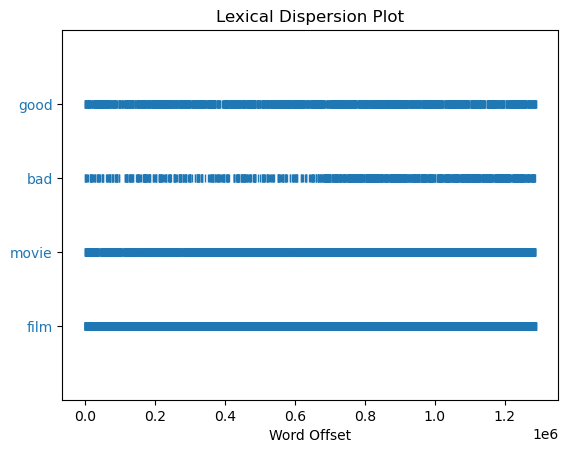

In [47]:
import nltk
from nltk.text import Text
text_obj = Text(all_words)
text_obj.dispersion_plot(["good", "bad", "movie", "film"])

Text data cannot be directly used in machine learning models, so it is converted into numerical form using TF-IDF.So TF-IDFMeasures importance of words. Reduces weight of common words and improves classification performance. Then model first used for logical regression. So Assigning weights to words and predicting probability of sentiment class

In [17]:
#convert text into numbers
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']

#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#train logical regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)  # increase iterations for convergence
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
#evalueate model
y_pred = model.predict(X_test) #prediction

from sklearn.metrics import accuracy_score #accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

from sklearn.metrics import classification_report #precision, recall, f1score
print(classification_report(y_test, y_pred))

Accuracy: 0.8175
              precision    recall  f1-score   support

           0       0.83      0.80      0.82       201
           1       0.81      0.83      0.82       199

    accuracy                           0.82       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.82      0.82      0.82       400



In [19]:
#performance
import time

start = time.time()
model.predict(X_test)
end = time.time()

avg_time = (end - start) / X_test.shape[0]

print("Average time per document:", avg_time)

Average time per document: 2.517104148864746e-06


Naive bayes model. Calculating probability of word occurrence in each class
Assuming independence between words. 

In [21]:
#naive bayes model
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [22]:
#evaluate model
y_pred = model.predict(X_test) #predictions

from sklearn.metrics import accuracy_score #accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

from sklearn.metrics import classification_report #precision, recal f1 score
print(classification_report(y_test, y_pred))

Accuracy: 0.805
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       201
           1       0.82      0.78      0.80       199

    accuracy                           0.81       400
   macro avg       0.81      0.80      0.80       400
weighted avg       0.81      0.81      0.80       400



In [23]:
#performance 
import time

start = time.time()
model.predict(X_test)
end = time.time()

avg_time = (end - start) / X_test.shape[0]

print("Average time per document:", avg_time)

Average time per document: 5.0514936447143555e-06


In [26]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.805


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.79      0.80       201
           1       0.79      0.82      0.81       199

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.80       400
weighted avg       0.81      0.81      0.80       400



In [26]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

In [34]:
y_pred_lr = model_lr.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
print("Accuracy:", acc_lr)
print("Precision:", prec_lr)
print("Recall:", rec_lr)
print("F1 Score:", f1_lr)

Accuracy: 0.8175
Precision: 0.8058252427184466
Recall: 0.8341708542713567
F1 Score: 0.8197530864197531


In [32]:
from sklearn.naive_bayes import MultinomialNB
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)
y_pred_nb = model_nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
print("Naive Bayes Results:")
print("Accuracy:", acc_nb)
print("Precision:", prec_nb)
print("Recall:", rec_nb)
print("F1 Score:", f1_nb)

Naive Bayes Results:
Accuracy: 0.805
Precision: 0.8201058201058201
Recall: 0.7788944723618091
F1 Score: 0.7989690721649485


In [35]:
models = ['Naive Bayes', 'Logistic Regression']
accuracy = [0.805, 0.8175]
precision = [0.8201, 0.8058]
recall = [0.7789, 0.8341]
f1 = [0.7990, 0.8198]

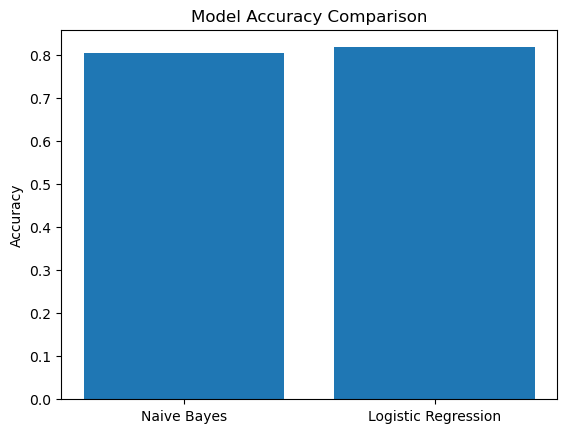

In [36]:
#accuracy comparition graph
import matplotlib.pyplot as plt
import numpy as np
plt.figure()
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

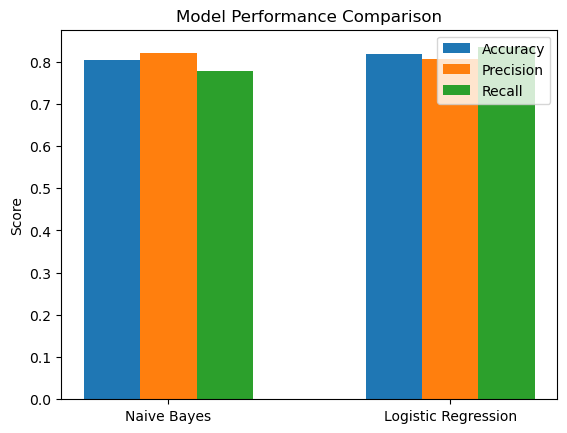

In [37]:
#full metrics compartition accuracy, recall and precision
x = np.arange(len(models))
width = 0.2
plt.figure()
plt.bar(x - width, accuracy, width, label='Accuracy')
plt.bar(x, precision, width, label='Precision')
plt.bar(x + width, recall, width, label='Recall')
plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.show()

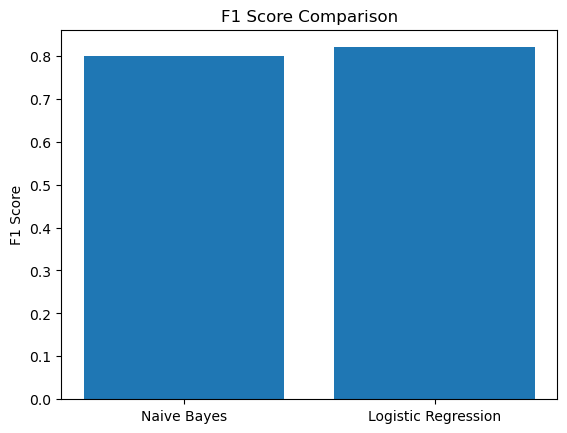

In [38]:
plt.figure()
plt.bar(models, f1)
plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.show()

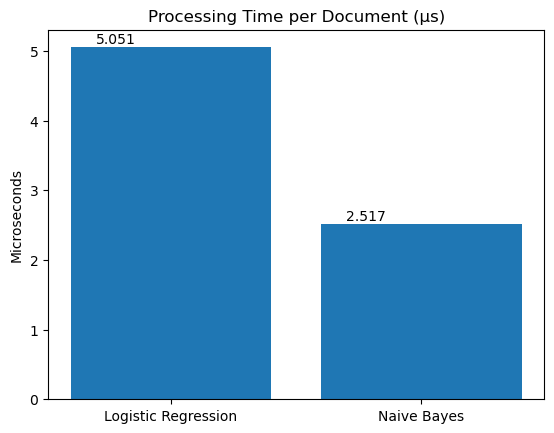

In [50]:
plt.figure()

bars = plt.bar(models, time_micro)

plt.title("Processing Time per Document (µs)")
plt.ylabel("Microseconds")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + 0.1, yval + 0.05, round(yval, 3))

plt.show()

In [52]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Naive Bayes']

# convert seconds → microseconds (µs)
time_per_doc = [
     2.517104148864746e-06 * 1e6,   # Logistic Regression
     5.0514936447143555e-06 * 1e6     # Naive Bayes (your value)
]